# CeBr3 (CH1)

In [1]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.stats import chi2
from datetime import date

---

# load data and get time

### background

In [2]:
bg = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_background\Energy_ch1.txt", skiprows=1)
channelsbg = bg[:, 0]
countsbg = bg[:, 1]
bgtime = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_background\Timestamp_ch1.txt", skiprows=1)
time = bgtime[:, 0]
t_bg = (time[-1] - time[0])* 1e-12

### Am241

In [3]:
am241 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Am241\Energy_ch1.txt", skiprows=1)
channelsam241 = am241[:, 0]
countsam241 = am241[:, 1]
am241time = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Am241\Timestamp_ch1.txt", skiprows=1)
time241 = am241time[:, 0]
t_am241 = (time241[-1] - time241[0])* 1e-12

### Co60

In [4]:
co60 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Co_60\Energy_ch1.txt", skiprows=1)
channelsco60 = co60[:, 0]
countsco60 = co60[:, 1]
co60time = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Co_60\Timestamp_ch1.txt", skiprows=1)
time60 = co60time[:, 0]
t_co60 = (time60[-1] - time60[0])* 1e-12

### Cs137

In [5]:
cs137 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Cs137\Energy_ch1.txt", skiprows=1)
channelscs137 = cs137[:, 0]
countscs137 = cs137[:, 1]
cs137time = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Cs137\Timestamp_ch1.txt", skiprows=1)
time137 = cs137time[:, 0]
t_cs137 = (time137[-1] - time137[0])* 1e-12

### Eu152

In [6]:
eu152 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Eu152\Energy_ch1.txt", skiprows=1)
channelseu152 = eu152[:, 0]
countseu152 = eu152[:, 1]
eu152time = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Eu152\Timestamp_ch1.txt", skiprows=1)
time152 = eu152time[:, 0]
t_eu152 = (time152[-1] - time152[0])* 1e-12

### Na22

In [7]:
na22 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Na22\Energy_ch1.txt", skiprows=1)
channelsna22 = na22[:, 0]
countsna22 = na22[:, 1]
na22time = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Na22\Timestamp_ch1.txt", skiprows=1)
time22 = na22time[:, 0]
t_na22 = (time22[-1] - time22[0])* 1e-12

---

# subtract background

### background

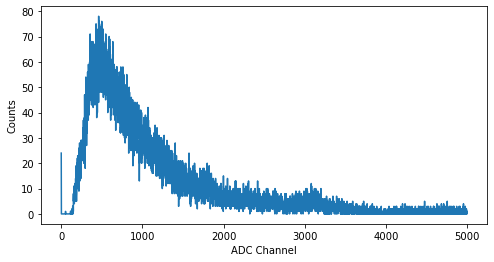

In [8]:
#spectrum background
range_ = (channelsbg > 0) & (channelsbg < 5000)
plt.figure(figsize=(8, 4))
plt.plot(channelsbg[range_], countsbg[range_])
plt.xlabel("ADC Channel")
plt.ylabel("Counts")
plt.show()

### Am241

In [9]:
counts_bg_am241 = countsbg * (t_am241 / t_bg)
netcountsam241 = countsam241 - counts_bg_am241
netcountsam241[netcountsam241 < 0] = 0

In [10]:
range_am241 = (channelsam241 > 0) & (channelsam241 < 8000)

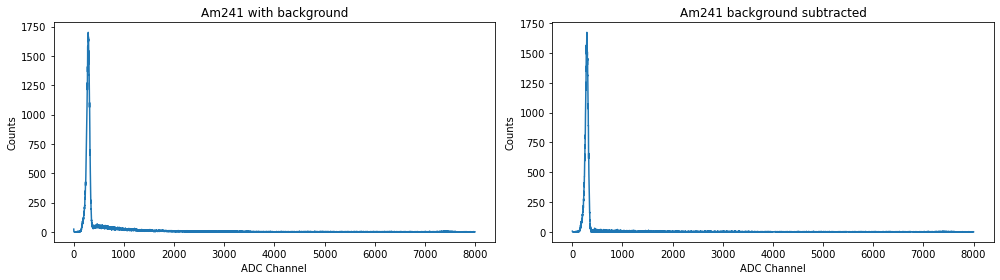

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))  # 1 row, 2 columns

ax[0].plot(channelsam241[range_am241], countsam241[range_am241])
ax[0].set_title("Am241 with background")
ax[0].set_xlabel("ADC Channel")
ax[0].set_ylabel("Counts")

ax[1].plot(channelsam241[range_am241], netcountsam241[range_am241])
ax[1].set_title("Am241 background subtracted")
ax[1].set_xlabel("ADC Channel")
ax[1].set_ylabel("Counts")

plt.tight_layout()
plt.show()

### Co60

In [12]:
counts_bg_co60 = countsbg * (t_co60 / t_bg)
netcountsco60 = countsco60 - counts_bg_co60
netcountsco60[netcountsco60 < 0] = 0

In [13]:
range_co60 = (channelsco60 > 0) & (channelsco60 < 8000)

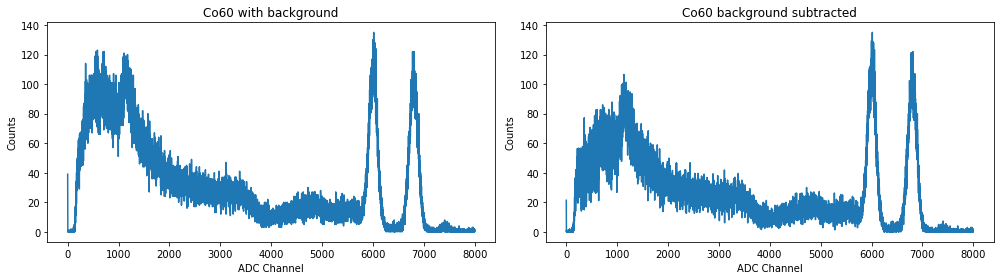

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))  # 1 row, 2 columns

ax[0].plot(channelsco60[range_co60], countsco60[range_co60])
ax[0].set_title("Co60 with background")
ax[0].set_xlabel("ADC Channel")
ax[0].set_ylabel("Counts")

ax[1].plot(channelsco60[range_co60], netcountsco60[range_co60])
ax[1].set_title("Co60 background subtracted")
ax[1].set_xlabel("ADC Channel")
ax[1].set_ylabel("Counts")

plt.tight_layout()
plt.show()

### Cs137

In [15]:
counts_bg_cs137 = countsbg * (t_cs137 / t_bg)
netcountscs137 = countscs137 - counts_bg_cs137
netcountscs137[netcountscs137 < 0] = 0

In [16]:
range_cs137 = (channelscs137 > 0) & (channelscs137 < 8000)

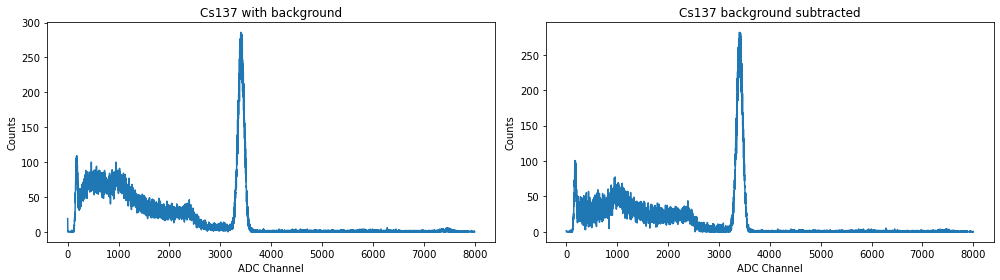

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))  # 1 row, 2 columns

ax[0].plot(channelscs137[range_cs137], countscs137[range_cs137])
ax[0].set_title("Cs137 with background")
ax[0].set_xlabel("ADC Channel")
ax[0].set_ylabel("Counts")

ax[1].plot(channelscs137[range_cs137], netcountscs137[range_cs137])
ax[1].set_title("Cs137 background subtracted")
ax[1].set_xlabel("ADC Channel")
ax[1].set_ylabel("Counts")

plt.tight_layout()
plt.show()

### Eu152

In [18]:
counts_bg_eu152 = countsbg * (t_eu152 / t_bg)
netcountseu152 = countseu152 - counts_bg_eu152
netcountseu152[netcountseu152 < 0] = 0

In [19]:
range_eu152 = (channelseu152 > 0) & (channelseu152 < 8000)

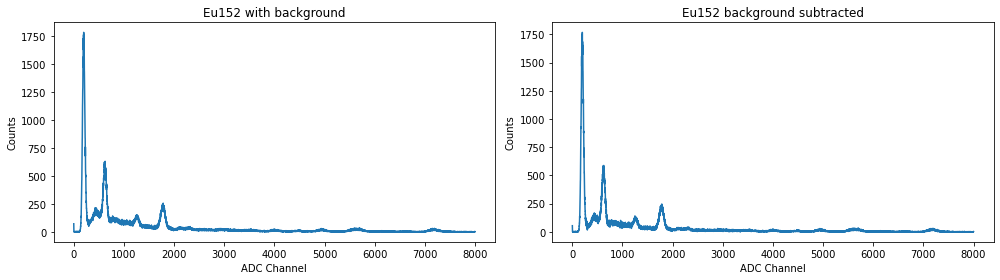

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))  # 1 row, 2 columns

ax[0].plot(channelseu152[range_eu152], countseu152[range_eu152])
ax[0].set_title("Eu152 with background")
ax[0].set_xlabel("ADC Channel")
ax[0].set_ylabel("Counts")

ax[1].plot(channelseu152[range_eu152], netcountseu152[range_eu152])
ax[1].set_title("Eu152 background subtracted")
ax[1].set_xlabel("ADC Channel")
ax[1].set_ylabel("Counts")

plt.tight_layout()
plt.show()

### Na22

In [21]:
counts_bg_na22 = countsbg * (t_na22 / t_bg)
netcountsna22 = countsna22 - counts_bg_na22
netcountsna22[netcountsna22 < 0] = 0

In [22]:
range_na22 = (channelsna22 > 0) & (channelsna22 < 8000)

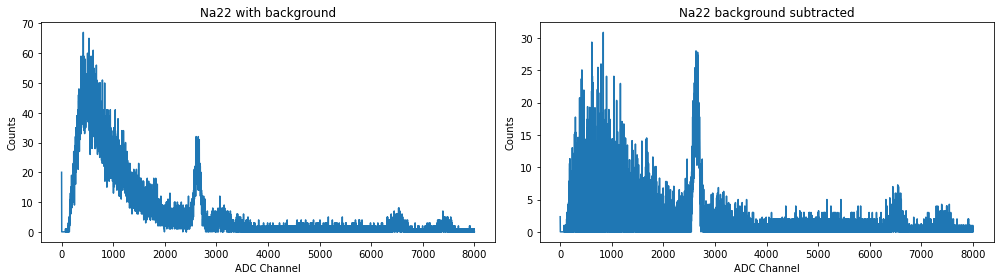

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))  # 1 row, 2 columns

ax[0].plot(channelsna22[range_na22], countsna22[range_na22])
ax[0].set_title("Na22 with background")
ax[0].set_xlabel("ADC Channel")
ax[0].set_ylabel("Counts")

ax[1].plot(channelsna22[range_na22], netcountsna22[range_na22])
ax[1].set_title("Na22 background subtracted")
ax[1].set_xlabel("ADC Channel")
ax[1].set_ylabel("Counts")

plt.tight_layout()
plt.show()

---

# Statistical errors

counting experiments -> Poisson statistics (sigma_i = sqrt(#counts_i)) 

### Am241

In [24]:
sigma_countsam241 = np.sqrt(countsam241 + (t_am241/t_bg)**2 * countsbg)
sigma_countsam241[sigma_countsam241 == 0] = 1

### Co60

In [25]:
sigma_countsco60 = np.sqrt(countsco60 + (t_co60/t_bg)**2 * countsbg)
sigma_countsco60[sigma_countsco60 == 0] = 1

### Cs137

In [26]:
sigma_countscs137 = np.sqrt(countscs137 + (t_cs137/t_bg)**2 * countsbg)
sigma_countscs137[sigma_countscs137 == 0] = 1

### Eu152

In [27]:
sigma_countseu152 = np.sqrt(countseu152 + (t_eu152/t_bg)**2 * countsbg)
sigma_countseu152[sigma_countseu152 == 0] = 1

### Na22

In [28]:
sigma_countsna22 = np.sqrt(countsna22 + (t_na22/t_bg)**2 * countsbg)
sigma_countsna22[sigma_countsna22 == 0] = 1

---

# Peak information

### Am241

In [29]:
activity = 39886.5
halflife = 433
d0 = date(1980, 1, 1)
d1 = date(2026, 3, 4)
delta_t = (d1-d0).total_seconds()
current_a = activity*np.exp((-np.log(2)*delta_t)/(halflife*365.25*24*3600)) 
print(current_a)

37044.76756957139


In [30]:
energies_am241 = [59.54]
channels_am241 = [290.5]
intensities_am241 = [35.9]
activity_am241 = [37044.76756957139]
time_am241 = [t_am241]

### Co60

In [31]:
activity = 19900
halflife = 5.27
d0 = date(2021, 4, 21)
d1 = date(2026, 3, 4)
delta_t = (d1-d0).total_seconds()
current_a = activity*np.exp((-np.log(2)*delta_t)/(halflife*365.25*24*3600)) 
print(current_a)

10490.391264996459


In [32]:
energies_co60 = [1173.228, 1332.492]
channels_co60 = [6005.3, 6801.6]
intensities_co60 = [99.85, 99.98]
activity_co60 = [10490.391264996459, 10490.391264996459]
time_co60 = [t_co60, t_co60]

### Cs137

In [33]:
activity = 41900
halflife = 30.1
d0 = date(1995, 2, 27)
d1 = date(2026, 3, 4)
delta_t = (d1-d0).total_seconds()
current_a = activity*np.exp((-np.log(2)*delta_t)/(halflife*365.25*24*3600)) 
print(current_a)

20513.481729860778


In [34]:
energies_cs137 = [661.657]
channels_cs137 = [3409.5]
intensities_cs137 = [85.1]
activity_cs137 = [20513.481729860778]
time_cs137 = [t_cs137]

### Eu152

In [35]:
activity = 45200
halflife = 13.33
d0 = date(2010, 6, 1)
d1 = date(2026, 3, 4)
delta_t = (d1-d0).total_seconds()
current_a = activity*np.exp((-np.log(2)*delta_t)/(halflife*365.25*24*3600)) 
print(current_a)

19921.17055278628


In [36]:
energies_eu152 = [121.7817, 244.6974, 344.2785, 778.904, 964.057]
channels_eu152 = [621.3, 1261.2, 1777.5, 4011.5, 4946.4]
intensities_eu152 = [28.41, 7.6, 26.6, 12.9, 14.6]
activity_eu152 = [19921.17055278628, 19921.17055278628, 19921.17055278628, 19921.17055278628, 19921.17055278628]
time_eu152 = [t_eu152, t_eu152, t_eu152, t_eu152, t_eu152]

### Na22

In [37]:
activity = 36200
halflife = 2.6
d0 = date(2010, 6, 1)
d1 = date(2026, 3, 4)
delta_t = (d1-d0).total_seconds()
current_a = activity*np.exp((-np.log(2)*delta_t)/(halflife*365.25*24*3600)) 
print(current_a)

542.5358499132185


In [38]:
energies_na22 = [511]
channels_na22 = [2635.9]
intensities_na22 = [179.8]
activity_na22 = [542.5358499132185]
time_na22 = [t_na22]

---

# Fit peaks

In [39]:
def model(x, A, mu, sigma, B, c):
    return (A / (np.sqrt(2*np.pi)*sigma)) * np.exp(-(x-mu)**2/(2*sigma**2)) + B*x + c

### Am241

Counts (A): 96126.54 ± 973.40
Mean (mu): 290.76 ± 0.15
Sigma: 25.77 ± 0.20
Background linear (B): -2.0263 ± 0.0652
Background constant (c): 707.01 ± 21.91

Reduced chi²: 1.3968797999
P-value: 0.002261907610778
[96126.53702045369]
[290.7568077466949]
[25.768309394980328]


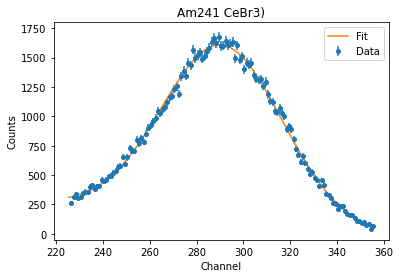

In [40]:
counts_listam241 = []
countserr_listam241 = []
mu_listam241 = []
muerr_listam241 = []
sigma_listam241 = []
sigmaerr_listam241 = []

peak_channel_guess = channels_am241[0] 
fit_width = 65  

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelsam241 >= xmin) & (channelsam241 <= xmax)

x = channelsam241[mask]
y = netcountsam241[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countsam241[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countsam241[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listam241.append(A)
countserr_listam241.append(A_err)
print(counts_listam241)
mu_listam241.append(mu)
muerr_listam241.append(mu_err)
print(mu_listam241)
sigma_listam241.append(sigma)
sigmaerr_listam241.append(sigma_err)
print(sigma_listam241)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countsam241[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Am241 CeBr3)")

plt.legend()
plt.show()

### Co60

Counts (A): 21117.92 ± 226.94
Mean (mu): 6004.87 ± 0.74
Sigma: 80.18 ± 0.78
Background linear (B): -0.0182 ± 0.0012
Background constant (c): 114.64 ± 7.56

Reduced chi²: 0.9339743820
P-value: 0.851108286724418
[21117.922681358596]
[6004.871695735731]
[80.17519066413269]


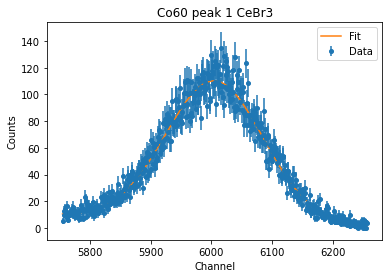

In [41]:
counts_listco60 = [] 
countserr_listco60 = []
mu_listco60 = []
muerr_listco60 = []
sigma_listco60 = []
sigmaerr_listco60 = []

peak_channel_guess = channels_co60[0] 
fit_width = 250

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelsco60 >= xmin) & (channelsco60 <= xmax)

x = channelsco60[mask]
y = netcountsco60[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countsco60[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countsco60[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listco60.append(A)
countserr_listco60.append(A_err)
print(counts_listco60)
mu_listco60.append(mu)
muerr_listco60.append(mu_err)
print(mu_listco60)
sigma_listco60.append(sigma)
sigmaerr_listco60.append(sigma_err)
print(sigma_listco60)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countsco60[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Co60 peak 1 CeBr3")

plt.legend()
plt.show()

Counts (A): 21868.64 ± 241.11
Mean (mu): 6801.37 ± 0.77
Sigma: 86.09 ± 0.86
Background linear (B): -0.0025 ± 0.0011
Background constant (c): 16.77 ± 7.56

Reduced chi²: 1.0948835027
P-value: 0.074951679794366
[21117.922681358596, 21868.64464410462]
[6004.871695735731, 6801.368160818817]
[80.17519066413269, 86.0939250344702]


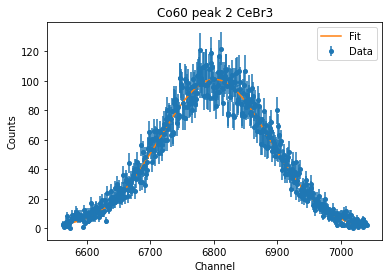

In [42]:
peak_channel_guess = channels_co60[1] 
fit_width = 240   

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelsco60 >= xmin) & (channelsco60 <= xmax)

x = channelsco60[mask]
y = netcountsco60[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countsco60[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countsco60[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listco60.append(A)
counts_listco60[1] = A
countserr_listco60.append(A_err)
countserr_listco60[1] = A_err
print(counts_listco60)
mu_listco60.append(mu)
mu_listco60[1] = mu
muerr_listco60.append(mu_err)
muerr_listco60[1] = mu_err
print(mu_listco60)
sigma_listco60.append(sigma)
sigma_listco60[1] = sigma
sigmaerr_listco60.append(sigma_err)
sigmaerr_listco60[1] = sigma_err
print(sigma_listco60)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countsco60[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Co60 peak 2 CeBr3")

plt.legend()
plt.show()

### Cs137

Counts (A): 38961.12 ± 237.34
Mean (mu): 3409.33 ± 0.36
Sigma: 60.24 ± 0.33
Background linear (B): -0.0104 ± 0.0015
Background constant (c): 36.30 ± 5.32

Reduced chi²: 1.1610296898
P-value: 0.014805908322376
[38961.1210232539]
[3409.3336738770845]
[60.235884859420445]


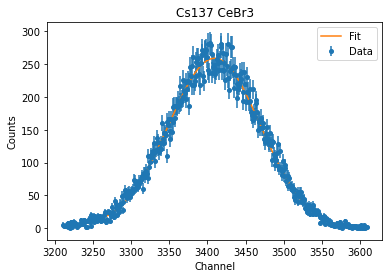

In [43]:
counts_listcs137 = [] 
countserr_listcs137 = []
mu_listcs137 = []
muerr_listcs137 = []
sigma_listcs137 = []
sigmaerr_listcs137 = []

peak_channel_guess = channels_cs137[0] 
fit_width = 200 

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelscs137 >= xmin) & (channelscs137 <= xmax)

x = channelscs137[mask]
y = netcountscs137[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countscs137[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countscs137[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listcs137.append(A)
countserr_listcs137.append(A_err)
print(counts_listcs137)
mu_listcs137.append(mu)
muerr_listcs137.append(mu_err)
print(mu_listcs137)
sigma_listcs137.append(sigma)
sigmaerr_listcs137.append(sigma_err)
print(sigma_listcs137)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countscs137[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Cs137 CeBr3")

plt.legend()
plt.show()

### Eu152

Counts (A): 35954.32 ± 438.91
Mean (mu): 621.39 ± 0.28
Sigma: 30.68 ± 0.32
Background linear (B): -0.2071 ± 0.0195
Background constant (c): 215.02 ± 12.53

Reduced chi²: 1.1325278125
P-value: 0.098820517539618
[35954.31639382867]
[621.386232522246]
[30.67679275460319]


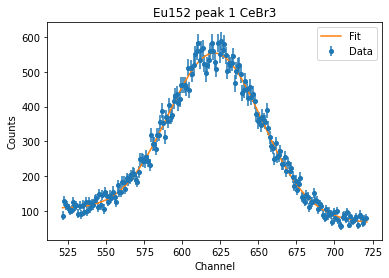

In [44]:
counts_listeu152 = [] 
countserr_listeu152 = []
mu_listeu152 = []
muerr_listeu152 = []
sigma_listeu152 = []
sigmaerr_listeu152 = []

peak_channel_guess = channels_eu152[0] 
fit_width = 100

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelseu152 >= xmin) & (channelseu152 <= xmax)

x = channelseu152[mask]
y = netcountseu152[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countseu152[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countseu152[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listeu152.append(A)
countserr_listeu152.append(A_err)
print(counts_listeu152)
mu_listeu152.append(mu)
muerr_listeu152.append(mu_err)
print(mu_listeu152)
sigma_listeu152.append(sigma)
sigmaerr_listeu152.append(sigma_err)
print(sigma_listeu152)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countseu152[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Eu152 peak 1 CeBr3")

plt.legend()
plt.show()

Counts (A): 7365.15 ± 442.92
Mean (mu): 1260.88 ± 1.19
Sigma: 37.28 ± 1.63
Background linear (B): -0.0701 ± 0.0153
Background constant (c): 132.00 ± 19.65

Reduced chi²: 0.9342571483
P-value: 0.735653168652815
[35954.31639382867, 7365.153139268824]
[621.386232522246, 1260.8806789140901]
[30.67679275460319, 37.2760689130764]


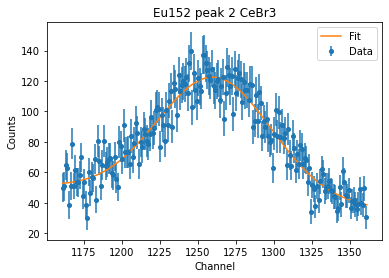

In [45]:
peak_channel_guess = channels_eu152[1] 
fit_width = 100

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelseu152 >= xmin) & (channelseu152 <= xmax)

x = channelseu152[mask]
y = netcountseu152[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countseu152[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countseu152[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listeu152.append(A)
counts_listeu152[1] = A
countserr_listeu152.append(A_err)
countserr_listeu152[1] = A_err
print(counts_listeu152)
mu_listeu152.append(mu)
mu_listeu152[1] = mu
muerr_listeu152.append(mu_err)
muerr_listeu152[1] = mu_err
print(mu_listeu152)
sigma_listeu152.append(sigma)
sigma_listeu152[1] = sigma
sigmaerr_listeu152.append(sigma_err)
sigmaerr_listeu152[1] = sigma_err
print(sigma_listeu152)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countseu152[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Eu152 peak 2 CeBr3")

plt.legend()
plt.show()

Counts (A): 21394.90 ± 458.97
Mean (mu): 1777.91 ± 0.58
Sigma: 45.14 ± 0.75
Background linear (B): -0.0284 ± 0.0101
Background constant (c): 75.96 ± 18.12

Reduced chi²: 1.0256675800
P-value: 0.379582841273812
[35954.31639382867, 7365.153139268824, 21394.89882868013]
[621.386232522246, 1260.8806789140901, 1777.9112265359224]
[30.67679275460319, 37.2760689130764, 45.140723589900404]


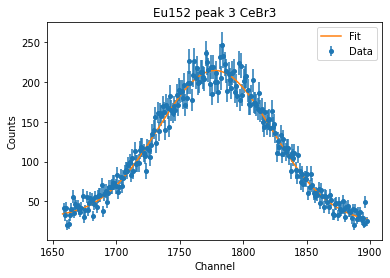

In [46]:
peak_channel_guess = channels_eu152[2] 
fit_width = 120

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelseu152 >= xmin) & (channelseu152 <= xmax)

x = channelseu152[mask]
y = netcountseu152[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countseu152[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countseu152[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listeu152.append(A)
counts_listeu152[2] = A
countserr_listeu152.append(A_err)
countserr_listeu152[2] = A_err
print(counts_listeu152)
mu_listeu152.append(mu)
mu_listeu152[2] = mu
muerr_listeu152.append(mu_err)
muerr_listeu152[2] = mu_err
print(mu_listeu152)
sigma_listeu152.append(sigma)
sigma_listeu152[2] = sigma
sigmaerr_listeu152.append(sigma_err)
sigmaerr_listeu152[2] = sigma_err
print(sigma_listeu152)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countseu152[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Eu152 peak 3 CeBr3")

plt.legend()
plt.show()

Counts (A): 1656.34 ± 80.62
Mean (mu): 4011.72 ± 2.65
Sigma: 64.05 ± 2.85
Background linear (B): -0.0023 ± 0.0007
Background constant (c): 12.19 ± 2.85

Reduced chi²: 1.1205459913
P-value: 0.032433443208044
[35954.31639382867, 7365.153139268824, 21394.89882868013, 1656.3413355454609]
[621.386232522246, 1260.8806789140901, 1777.9112265359224, 4011.715111702358]
[30.67679275460319, 37.2760689130764, 45.140723589900404, 64.0522899610122]


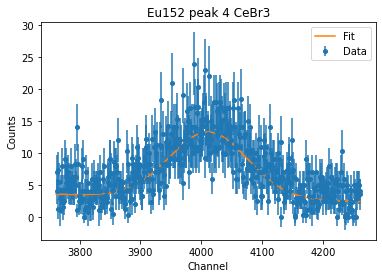

In [47]:
peak_channel_guess = channels_eu152[3] 
fit_width = 250

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelseu152 >= xmin) & (channelseu152 <= xmax)

x = channelseu152[mask]
y = netcountseu152[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countseu152[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countseu152[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listeu152.append(A)
counts_listeu152[3] = A
countserr_listeu152.append(A_err)
countserr_listeu152[3] = A_err
print(counts_listeu152)
mu_listeu152.append(mu)
mu_listeu152[3] = mu
muerr_listeu152.append(mu_err)
muerr_listeu152[3] = mu_err
print(mu_listeu152)
sigma_listeu152.append(sigma)
sigma_listeu152[3] = sigma
sigmaerr_listeu152.append(sigma_err)
sigmaerr_listeu152[3] = sigma_err
print(sigma_listeu152)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countseu152[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Eu152 peak 4 CeBr3")

plt.legend()
plt.show()

Counts (A): 2278.49 ± 107.81
Mean (mu): 4945.19 ± 2.47
Sigma: 68.84 ± 2.83
Background linear (B): 0.0003 ± 0.0009
Background constant (c): 1.28 ± 4.69

Reduced chi²: 1.0059802788
P-value: 0.455960978901635
[35954.31639382867, 7365.153139268824, 21394.89882868013, 1656.3413355454609, 2278.4924788882013]
[621.386232522246, 1260.8806789140901, 1777.9112265359224, 4011.715111702358, 4945.194362450161]
[30.67679275460319, 37.2760689130764, 45.140723589900404, 64.0522899610122, 68.8400243992991]


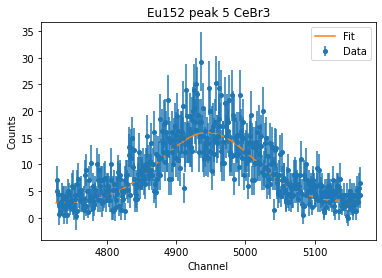

In [48]:
peak_channel_guess = channels_eu152[4] 
fit_width = 220

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelseu152 >= xmin) & (channelseu152 <= xmax)

x = channelseu152[mask]
y = netcountseu152[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countseu152[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countseu152[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listeu152.append(A)
counts_listeu152[4] = A
countserr_listeu152.append(A_err)
countserr_listeu152[4] = A_err
print(counts_listeu152)
mu_listeu152.append(mu)
mu_listeu152[4] = mu
muerr_listeu152.append(mu_err)
muerr_listeu152[4] = mu_err
print(mu_listeu152)
sigma_listeu152.append(sigma)
sigma_listeu152[4] = sigma
sigmaerr_listeu152.append(sigma_err)
sigmaerr_listeu152[4] = sigma_err
print(sigma_listeu152)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countseu152[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Eu152 peak 5 CeBr3")

plt.legend()
plt.show()

### Na22

Counts (A): 2552.18 ± 105.95
Mean (mu): 2636.48 ± 1.83
Sigma: 54.26 ± 2.00
Background linear (B): -0.0004 ± 0.0014
Background constant (c): 1.94 ± 3.70

Reduced chi²: 0.6599065457
P-value: 0.999999872146697
[2552.177316818834]
[2636.4785842939305]
[54.263665486308916]


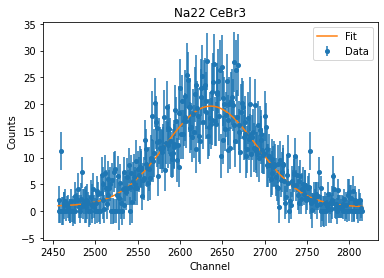

In [49]:
counts_listna22 = [] 
countserr_listna22 = []
mu_listna22 = []
muerr_listna22 = []
sigma_listna22 = []
sigmaerr_listna22 = []

peak_channel_guess = channels_na22[0] 
fit_width = 180

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelsna22 >= xmin) & (channelsna22 <= xmax)

x = channelsna22[mask]
y = netcountsna22[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countsna22[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countsna22[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listna22.append(A)
countserr_listna22.append(A_err)
print(counts_listna22)
mu_listna22.append(mu)
muerr_listna22.append(mu_err)
print(mu_listna22)
sigma_listna22.append(sigma)
sigmaerr_listna22.append(sigma_err)
print(sigma_listna22)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countsna22[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Na22 CeBr3")

plt.legend()
plt.show()

---

# Energy calibration 

In [50]:
counts_list = counts_listam241 + counts_listco60 + counts_listcs137 + counts_listeu152 + counts_listna22
counts_err_list = countserr_listam241 + countserr_listco60 + countserr_listcs137 + countserr_listeu152 + countserr_listna22
mu_list = mu_listam241 + mu_listco60 + mu_listcs137 + mu_listeu152 + mu_listna22
mu_err_list = muerr_listam241 + muerr_listco60 + muerr_listcs137 + muerr_listeu152 + muerr_listna22
sigma_list = sigma_listam241 + sigma_listco60 + sigma_listcs137 + sigma_listeu152 + sigma_listna22
sigma_err_list = sigmaerr_listam241 + sigmaerr_listco60 + sigmaerr_listcs137 + sigmaerr_listeu152 + sigmaerr_listna22
energy_list = energies_am241 + energies_co60 + energies_cs137 + energies_eu152 + energies_na22
intensities_list = intensities_am241 + intensities_co60 + intensities_cs137 + intensities_eu152 + intensities_na22
activity_list = activity_am241 + activity_co60 + activity_cs137 + activity_eu152 + activity_na22
time_list = time_am241 + time_co60 + time_cs137 + time_eu152 + time_na22

print(len(counts_list))
print(len(mu_list))
print(len(sigma_list))
print(len(energy_list))
print(len(intensities_list))
print(len(activity_list))
print(len(time_list))

10
10
10
10
10
10
10


In [51]:
counts_array = np.array(counts_list)
counts_err_array = np.array(counts_err_list)
mu_array = np.array(mu_list)
mu_err_array = np.array(mu_err_list)
sigma_array = np.array(sigma_list)
sigma_err_array = np.array(sigma_err_list)
energy_array = np.array(energy_list)
intensities_array = np.array(intensities_list)/100
activity_array = np.array(activity_list)
time_array = np.array(time_list)

### linear fit

In [52]:
def energy_calib_linear(x, A, B):
    return A*x + B

Calibration results:
A = 1.945012e-01 ± 4.711900e-04
B = 2.109962e+00 ± 8.966076e-01


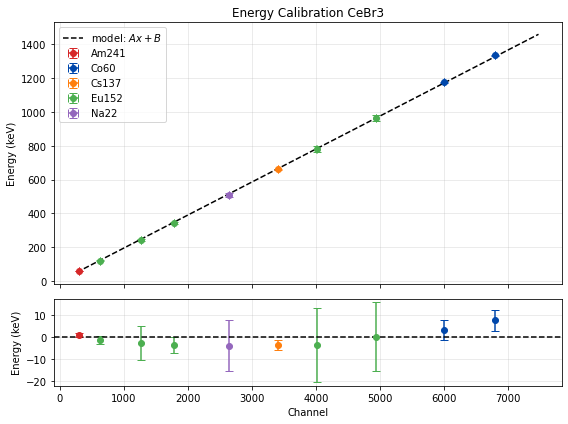

Before rescaling:
Reduced chi²: 1036.851
P-value: 0.0000

After rescaling:
Reduced chi²: 1.000
P-value: 0.4335


In [53]:
# initial guess
p0 = [1, 2]

# temporary fit (needed to estimate sigma_E)
popt_temp, _ = curve_fit(energy_calib_linear, mu_array, energy_array, p0=p0)

A_temp, B_temp = popt_temp

# propagate errors
sigma_E = np.abs(A_temp) * mu_err_array

# avoid zeros
sigma_E[sigma_E == 0] = 1

# FIRST FIT
popt, pcov = curve_fit(
    energy_calib_linear,
    mu_array,
    energy_array,
    sigma=sigma_E,
    absolute_sigma=True
)

# compute chi2 with initial uncertainties
E_fit_initial = energy_calib_linear(mu_array, *popt)
chi2_val_initial = np.sum(((energy_array - E_fit_initial)/sigma_E)**2)
ndof = len(mu_array) - len(popt)
chi2_red_initial = chi2_val_initial / ndof
p_value_initial = 1 - chi2.cdf(chi2_val_initial, ndof)

# rescale uncertainties 
scale_factor = np.sqrt(chi2_red_initial)
sigma_E_scaled = sigma_E * scale_factor

# FINAL FIT
popt, pcov = curve_fit(
    energy_calib_linear,
    mu_array,
    energy_array,
    sigma=sigma_E_scaled,
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, B = popt
A_err, B_err = perr

print("Calibration results:")
print(f"A = {A:.6e} ± {A_err:.6e}")
print(f"B = {B:.6e} ± {B_err:.6e}")

residuals = energy_array - energy_calib_linear(mu_array, *popt)

E_fit = energy_calib_linear(mu_array, *popt)
chi2_val = np.sum(((energy_array - E_fit)/sigma_E_scaled)**2)
ndof = len(mu_array) - len(popt)
chi2_red = chi2_val / ndof

p_value = 1 - chi2.cdf(chi2_val, ndof)

fig, (ax_main, ax_resid) = plt.subplots(2, 1, 
                                        sharex=True,
                                        gridspec_kw={'height_ratios':[3,1]},
                                        figsize=(8,6))

# --- Main plot ---
x_plot = np.linspace(min(mu_array)*0.9, max(mu_array)*1.1, 500)
ax_main.errorbar(mu_array[0], energy_array[0], xerr=mu_err_array[0], yerr=sigma_E_scaled[0], fmt='o', color='#d62728', label='Am241', capsize=4)
ax_main.errorbar(mu_array[1:3], energy_array[1:3], xerr=mu_err_array[1:3], yerr=sigma_E_scaled[1:3], fmt='o', color='#0047AB', label='Co60', capsize=4)
ax_main.errorbar(mu_array[3], energy_array[3], xerr=mu_err_array[3], yerr=sigma_E_scaled[3], fmt='o', color='#ff7f0e', label='Cs137', capsize=4)
ax_main.errorbar(mu_array[4:9], energy_array[4:9], xerr=mu_err_array[4:9], yerr=sigma_E_scaled[4:9], fmt='o', color='#4CAF50', label='Eu152', capsize=4)
ax_main.errorbar(mu_array[9], energy_array[9], xerr=mu_err_array[9], yerr=sigma_E_scaled[9], fmt='o', color='#9467bd', label='Na22', capsize=4)
ax_main.plot(x_plot, energy_calib_linear(x_plot, *popt), 'k--', label=r'model: $Ax + B$')
ax_main.set_ylabel("Energy (keV)")
ax_main.legend()
ax_main.set_title("Energy Calibration CeBr3")
ax_main.grid(True, alpha=0.3)


# --- Residuals plot ---
ax_resid.errorbar(mu_array[0], residuals[0], yerr=sigma_E_scaled[0], color='#d62728', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[1:3], residuals[1:3], yerr=sigma_E_scaled[1:3], color='#0047AB', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[3], residuals[3], yerr=sigma_E_scaled[3], color='#ff7f0e', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[4:9], residuals[4:9], yerr=sigma_E_scaled[4:9], color='#4CAF50', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[9], residuals[9], yerr=sigma_E_scaled[9], color='#9467bd', fmt='o', capsize=4)
ax_resid.axhline(0, color='black', linestyle='--')
ax_resid.set_xlabel("Channel")
ax_resid.set_ylabel("Energy (keV)")
ax_resid.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print("Before rescaling:")
print(f"Reduced chi²: {chi2_red_initial:.3f}")
print(f"P-value: {p_value_initial:.4f}")
print()
print("After rescaling:")
print(f"Reduced chi²: {chi2_red:.3f}")
print(f"P-value: {p_value:.4f}")

### quadratic fit

In [54]:
def energy_calib(x, A, B, C):
    return A*x**2 + B*x + C

Calibration results:
A = 7.513356e-07 ± 5.027183e-08
B = 1.902442e-01 ± 2.960588e-04
C = 3.983360e+00 ± 2.044233e-01


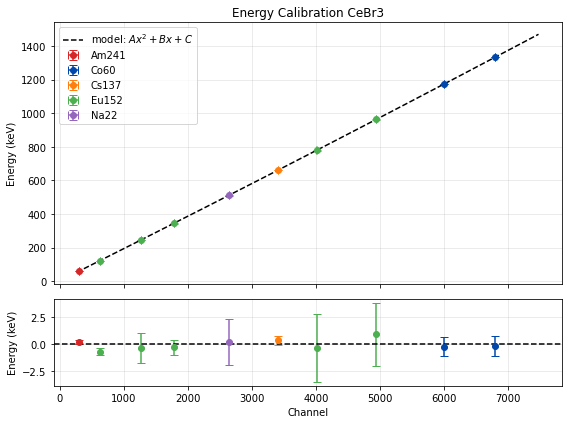

Before rescaling:
Reduced chi²: 35.815
P-value: 0.0000

After rescaling:
Reduced chi²: 1.000
P-value: 0.4289


In [55]:
# initial guess
p0 = [0, 1, 2]

# temporary fit (needed to estimate sigma_E)
popt_temp, _ = curve_fit(energy_calib, mu_array, energy_array, p0=p0)

A_temp, B_temp, C_temp = popt_temp

# propagate errors
sigma_E = np.abs(2*A_temp*mu_array + B_temp) * mu_err_array

# avoid zeros
sigma_E[sigma_E == 0] = 1

# FIRST FIT
popt, pcov = curve_fit(
    energy_calib,
    mu_array,
    energy_array,
    sigma=sigma_E,
    absolute_sigma=True
)

# compute chi2 with initial uncertainties
E_fit_initial = energy_calib(mu_array, *popt)
chi2_val_initial = np.sum(((energy_array - E_fit_initial)/sigma_E)**2)
ndof = len(mu_array) - len(popt)
chi2_red_initial = chi2_val_initial / ndof

p_value_initial = 1 - chi2.cdf(chi2_val_initial, ndof)

# rescale uncertainties
scale_factor = np.sqrt(chi2_red_initial)
sigma_E_scaled = sigma_E * scale_factor

# FINAL FIT
popt, pcov = curve_fit(
    energy_calib,
    mu_array,
    energy_array,
    sigma=sigma_E_scaled,
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, B, C = popt
A_err, B_err, C_err = perr

print("Calibration results:")
print(f"A = {A:.6e} ± {A_err:.6e}")
print(f"B = {B:.6e} ± {B_err:.6e}")
print(f"C = {C:.6e} ± {C_err:.6e}")

residuals = energy_array - energy_calib(mu_array, *popt)

E_fit = energy_calib(mu_array, *popt)

chi2_val = np.sum(((energy_array - E_fit)/sigma_E_scaled)**2)
ndof = len(mu_array) - len(popt)
chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

fig, (ax_main, ax_resid) = plt.subplots(2, 1, 
                                        sharex=True,
                                        gridspec_kw={'height_ratios':[3,1]},
                                        figsize=(8,6))

# --- Main plot ---
x_plot = np.linspace(min(mu_array)*0.9, max(mu_array)*1.1, 500)
ax_main.errorbar(mu_array[0], energy_array[0], xerr=mu_err_array[0], yerr=sigma_E_scaled[0], fmt='o', color='#d62728', label='Am241', capsize=4)
ax_main.errorbar(mu_array[1:3], energy_array[1:3], xerr=mu_err_array[1:3], yerr=sigma_E_scaled[1:3], fmt='o', color='#0047AB', label='Co60', capsize=4)
ax_main.errorbar(mu_array[3], energy_array[3], xerr=mu_err_array[3], yerr=sigma_E_scaled[3], fmt='o', color='#ff7f0e', label='Cs137', capsize=4)
ax_main.errorbar(mu_array[4:9], energy_array[4:9], xerr=mu_err_array[4:9], yerr=sigma_E_scaled[4:9], fmt='o', color='#4CAF50', label='Eu152', capsize=4)
ax_main.errorbar(mu_array[9], energy_array[9], xerr=mu_err_array[9], yerr=sigma_E_scaled[9], fmt='o', color='#9467bd', label='Na22', capsize=4)
ax_main.plot(x_plot, energy_calib(x_plot, *popt), 'k--', label=r'model: $Ax^2 + Bx + C$')
ax_main.set_ylabel("Energy (keV)")
ax_main.legend()
ax_main.set_title("Energy Calibration CeBr3")
ax_main.grid(True, alpha=0.3)



# --- Residuals plot ---
ax_resid.errorbar(mu_array[0], residuals[0], yerr=sigma_E_scaled[0], color='#d62728', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[1:3], residuals[1:3], yerr=sigma_E_scaled[1:3], color='#0047AB', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[3], residuals[3], yerr=sigma_E_scaled[3], color='#ff7f0e', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[4:9], residuals[4:9], yerr=sigma_E_scaled[4:9], color='#4CAF50', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[9], residuals[9], yerr=sigma_E_scaled[9], color='#9467bd', fmt='o', capsize=4)
ax_resid.axhline(0, color='black', linestyle='--')
ax_resid.set_xlabel("Channel")
ax_resid.set_ylabel("Energy (keV)")
ax_resid.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

print("Before rescaling:")
print(f"Reduced chi²: {chi2_red_initial:.3f}")
print(f"P-value: {p_value_initial:.4f}")
print()
print("After rescaling:")
print(f"Reduced chi²: {chi2_red:.3f}")
print(f"P-value: {p_value:.4f}")

---

# Resolution

energy resolution: R(E) = FWHM/E , FWHM = 2.355 * sigma

sigma_E = |dE/dx| * sigma

E(x) = Ax² + Bx + C

dE/dx = 2Ax + B

In [56]:
print(2*np.sqrt(2*np.log(2)))

2.3548200450309493


In [57]:
dEdx = 2*A*mu_array + B

sigma_E = np.abs(dEdx) * sigma_array
FWHM_E = 2*np.sqrt(2*np.log(2)) * sigma_E

resolution = FWHM_E / energy_array

In [58]:
error_sigma = (dEdx * sigma_err_array)**2
error_mu = (2*A*sigma_array * mu_err_array)**2
error_A = (2*mu_array*sigma_array * A_err)**2
error_B = (sigma_array * B_err)**2

sigma_E_err = np.sqrt(error_sigma+error_mu+error_A+error_B)

In [59]:
FWHM_E_err = 2*np.sqrt(2*np.log(2)) * sigma_E_err

resolution_err = FWHM_E_err / energy_array

In [60]:
def resolution_model(E, A, B, C):
    return A/E + B/np.sqrt(E) + C

A = 6.8184e+00 ± 3.3045e-01
B = 5.2547e-01 ± 4.5652e-02
C = 1.1004e-02 ± 1.1845e-03


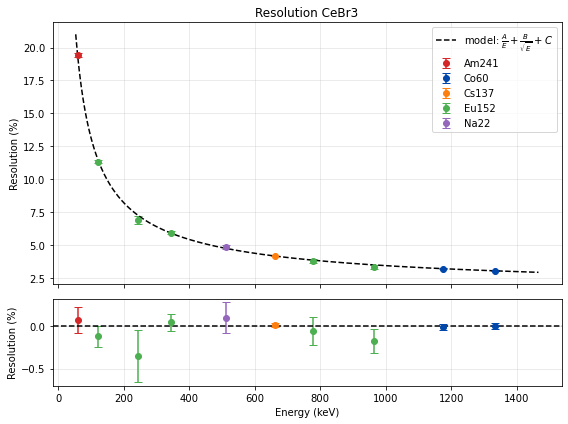

Reduced chi²: 0.749
P-value: 0.6302


In [61]:
# Fit the resolution
p0 = [1,1,0]
popt, pcov = curve_fit(
    resolution_model,
    energy_array,
    resolution,
    sigma=resolution_err,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))
A_res, B_res, C_res = popt

# Residuals
residuals = resolution - resolution_model(energy_array, *popt)

# --- Compute reduced chi² and p-value ---
chi2_val = np.sum((residuals / resolution_err)**2)
ndof = len(energy_array) - len(popt)
chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

# --- Plotting ---
fig, (ax_main, ax_resid) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]},
    figsize=(8,6)
)

print(f"A = {A_res:.4e} ± {perr[0]:.4e}")
print(f"B = {B_res:.4e} ± {perr[1]:.4e}")
print(f"C = {C_res:.4e} ± {perr[2]:.4e}")

# --- Main plot ---
E_plot = np.linspace(min(energy_array)*0.9, max(energy_array)*1.1, 500)

ax_main.errorbar(energy_array[0], resolution[0]*100, yerr=resolution_err[0]*100, fmt='o', color='#d62728', label='Am241', capsize=4)
ax_main.errorbar(energy_array[1:3], resolution[1:3]*100, yerr=resolution_err[1:3]*100, fmt='o', color='#0047AB', label='Co60', capsize=4)
ax_main.errorbar(energy_array[3], resolution[3]*100, yerr=resolution_err[3]*100, fmt='o', color='#ff7f0e', label='Cs137', capsize=4)
ax_main.errorbar(energy_array[4:9], resolution[4:9]*100, yerr=resolution_err[4:9]*100, fmt='o', color='#4CAF50', label='Eu152', capsize=4)
ax_main.errorbar(energy_array[9], resolution[9]*100, yerr=resolution_err[9]*100, fmt='o', color='#9467bd', label='Na22', capsize=4)
ax_main.plot(E_plot, resolution_model(E_plot, *popt)*100, 'k--', label=r'model: $\frac{A}{E} + \frac{B}{\sqrt{E}} + C$')
ax_main.set_ylabel("Resolution (%)")
ax_main.set_title("Resolution CeBr3")
ax_main.legend()
ax_main.grid(True, alpha=0.3)

ax_resid.errorbar(energy_array[0], residuals[0]*100, yerr=resolution_err[0]*100, fmt='o', color='#d62728', capsize=4)
ax_resid.errorbar(energy_array[1:3], residuals[1:3]*100, yerr=resolution_err[1:3]*100, fmt='o', color='#0047AB', capsize=4)
ax_resid.errorbar(energy_array[3], residuals[3]*100, yerr=resolution_err[3]*100, fmt='o', color='#ff7f0e', capsize=4)
ax_resid.errorbar(energy_array[4:9], residuals[4:9]*100, yerr=resolution_err[4:9]*100, fmt='o', color='#4CAF50', capsize=4)
ax_resid.errorbar(energy_array[9], residuals[9]*100, yerr=resolution_err[9]*100, fmt='o', color='#9467bd', capsize=4)
ax_resid.axhline(0, color='black', linestyle='--')
ax_resid.set_xlabel("Energy (keV)")
ax_resid.set_ylabel("Resolution (%)")
ax_resid.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Reduced chi²: {chi2_red:.3f}")
print(f"P-value: {p_value:.4f}")

---

# Absolute efficiency

absolute efficiency = # detected photons / # photons emitted by source

N_detected = counts (A) from Gaussian fit

N_emitted = activity * time * intensity 

In [62]:
# distance from source to crystal
d = 0.072 
# dimensions crystal 48mm x 48mm x 48mm
area = 0.048*0.048

In [63]:
# solid angle
omega = area/(d**2)
geom_factor = omega/(4*np.pi)
print(geom_factor)

0.03536776513153231


In [64]:
absolute_eff = counts_array/(activity_array*time_array*intensities_array)
intrinsic_eff = counts_array/(activity_array*time_array*intensities_array*geom_factor)

In [65]:
# error on solid angle 
# d = 7.2 +- 0.1 cm 
d_err = 0.001
omega_plus = area/((d+d_err)**2)
omega_minus = area/((d-d_err)**2)

omega_err = np.abs(omega_plus-omega_minus)/2
geom_factor_err = omega_err/(4*np.pi)

In [66]:
#error on efficiency
rel_counts = counts_err_array / counts_array
rel_geom_factor  = geom_factor_err / geom_factor

abs_eff_err = absolute_eff * np.sqrt(rel_counts**2)
int_eff_err = intrinsic_eff * np.sqrt(rel_counts**2 + rel_geom_factor**2)

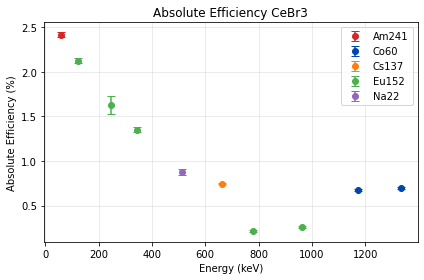

In [67]:
plt.errorbar(energy_array[0], absolute_eff[0]*100, yerr=abs_eff_err[0]*100, fmt='o', color='#d62728', label='Am241', capsize=4)
plt.errorbar(energy_array[1:3], absolute_eff[1:3]*100, yerr=abs_eff_err[1:3]*100, fmt='o', color='#0047AB', label='Co60', capsize=4)
plt.errorbar(energy_array[3], absolute_eff[3]*100, yerr=abs_eff_err[3]*100, fmt='o', color='#ff7f0e', label='Cs137', capsize=4)
plt.errorbar(energy_array[4:9], absolute_eff[4:9]*100, yerr=abs_eff_err[4:9]*100, fmt='o', color='#4CAF50', label='Eu152', capsize=4)
plt.errorbar(energy_array[9], absolute_eff[9]*100, yerr=abs_eff_err[9]*100, fmt='o', color='#9467bd', label='Na22', capsize=4)
plt.xlabel("Energy (keV)")
plt.ylabel("Absolute Efficiency (%)")
plt.title("Absolute Efficiency CeBr3")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

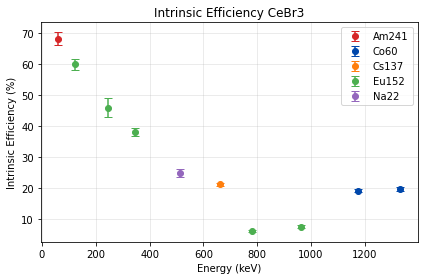

In [68]:
plt.errorbar(energy_array[0], intrinsic_eff[0]*100, yerr=int_eff_err[0]*100, fmt='o', color='#d62728', label='Am241', capsize=4)
plt.errorbar(energy_array[1:3], intrinsic_eff[1:3]*100, yerr=int_eff_err[1:3]*100, fmt='o', color='#0047AB', label='Co60', capsize=4)
plt.errorbar(energy_array[3], intrinsic_eff[3]*100, yerr=int_eff_err[3]*100, fmt='o', color='#ff7f0e', label='Cs137', capsize=4)
plt.errorbar(energy_array[4:9], intrinsic_eff[4:9]*100, yerr=int_eff_err[4:9]*100, fmt='o', color='#4CAF50', label='Eu152', capsize=4)
plt.errorbar(energy_array[9], intrinsic_eff[9]*100, yerr=int_eff_err[9]*100, fmt='o', color='#9467bd', label='Na22', capsize=4)
plt.xlabel("Energy (keV)")
plt.ylabel("Intrinsic Efficiency (%)")
plt.title("Intrinsic Efficiency CeBr3")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()